In [10]:
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchinfo import summary
from helper import normalize, denormalize, train_model, get_normalized_data, evaluate_model, denormalize_std
from model_examples import TinyCNN
import models
from scipy.stats import norm
import torch.nn.functional as F

In [11]:
# reload custom files:
import importlib
importlib.reload(models)



<module 'models' from '/mnt/shared/Uni/Master_2/Deep-Learning/models.py'>

In [12]:
DATA_PATH = "data_galah4"

# hyperparameters
batch_size = 32
learning_rate = 1e-4
num_epochs = 100
patience = 15
train_fraction = 0.7
val_fraction = 0.15
# choose if calculate uncertainty
calculate_uncertainty = True


# Call the function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)

# convert to tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# split into training, validation, and test sets
sample_size = len(spectra_tensor)
train_size = int(train_fraction * sample_size)
val_size = int(val_fraction * sample_size)
test_size = sample_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(67))

# create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



# select my own model
# model_choice = 'CNN_Astronomy'
# model_choice = 'TinyCNN'
model_choice = 'galah'
if calculate_uncertainty and model_choice == 'CNN_Astronomy':
     model = models.CNN_Astronomy(2 * n_labels)  # Output size is doubled for mean and log variance
elif model_choice == 'CNN_Astronomy':
     model = models.CNN_Astronomy(n_labels)  # Output size is n_labels for mean only
elif model_choice == 'TinyCNN':
     model = TinyCNN(2 * n_labels) if calculate_uncertainty else TinyCNN(n_labels)
elif model_choice == 'galah':
    model = models.galah(2 * n_labels)
else:
     raise ValueError("Invalid model choice.")

# Print the model summary before moving it to the device
summary(model, input_size=(1, 1, spectra_length))

# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Define loss function and optimizer
if calculate_uncertainty:
    criterion = nn.GaussianNLLLoss()
else:
    criterion = nn.MSELoss()

def nll_loss(predictions, batch_labels):
    mean = predictions[:, :n_labels]
    log_std = predictions[:, n_labels:]
    std = torch.exp(log_std)  
    return torch.mean((0.5 * ((batch_labels - mean) / std) ** 2) + log_std)

def loss_function(inputs, labels, model):
    predictions = model(inputs)
    
    loss = nll_loss(predictions, labels)
    return loss



# def loss_function(inputs, labels, model):
#     predictions = model(inputs)
#     mean = predictions[:, :n_labels]
#     log_std = predictions[:, n_labels:]

#     # Softplus safely enforces positive variance, 1e-6 prevents absolute zero
#     var = F.softplus(log_std) + 1e-6  
#     loss = criterion(mean, labels, var)
#     return loss




n_trainingsloops = 1

for i in range(n_trainingsloops):
    # call function
    train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device)

    # Final evaluation on the test dataset
    model.load_state_dict(best_model)  # Load the best model
    # save the best model to the "models" directory
    if not os.path.exists('Deep-Learning/models'):
        os.makedirs('Deep-Learning/models')
    torch.save(best_model, f'Deep-Learning/models/{model_choice}_uncertainty_best.pth')


Using device: cuda
Epoch [1/100], Step [190/195], Loss: -0.6534
Epoch [1/100], Train Loss: -0.5568, Val Loss: -0.6675, Time: 8.27 seconds
Epoch [2/100], Step [190/195], Loss: -0.7860
Epoch [2/100], Train Loss: -0.6264, Val Loss: -0.8196, Time: 7.30 seconds
Epoch [3/100], Step [190/195], Loss: -1.0185
Epoch [3/100], Train Loss: -0.8483, Val Loss: -1.0991, Time: 7.31 seconds
Epoch [4/100], Step [190/195], Loss: -1.0261
Epoch [4/100], Train Loss: -1.1196, Val Loss: -1.3625, Time: 7.34 seconds
Epoch [5/100], Step [190/195], Loss: -1.3375
Epoch [5/100], Train Loss: -1.2942, Val Loss: -1.4604, Time: 7.27 seconds
Epoch [6/100], Step [190/195], Loss: -1.1643
Epoch [6/100], Train Loss: -1.3937, Val Loss: -1.6383, Time: 7.13 seconds
Epoch [7/100], Step [190/195], Loss: -1.5016
Epoch [7/100], Train Loss: -1.4296, Val Loss: -1.6546, Time: 7.16 seconds
Epoch [8/100], Step [190/195], Loss: -1.5813
Epoch [8/100], Train Loss: -1.4787, Val Loss: -1.7392, Time: 7.20 seconds
Epoch [9/100], Step [190/195]

/tmp/ipykernel_25114/223287767.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'Deep-Learning/models/{model_choice}_uncertainty_best.pt

Evaluating model on the test dataset...
Final Test Loss: -2.1486


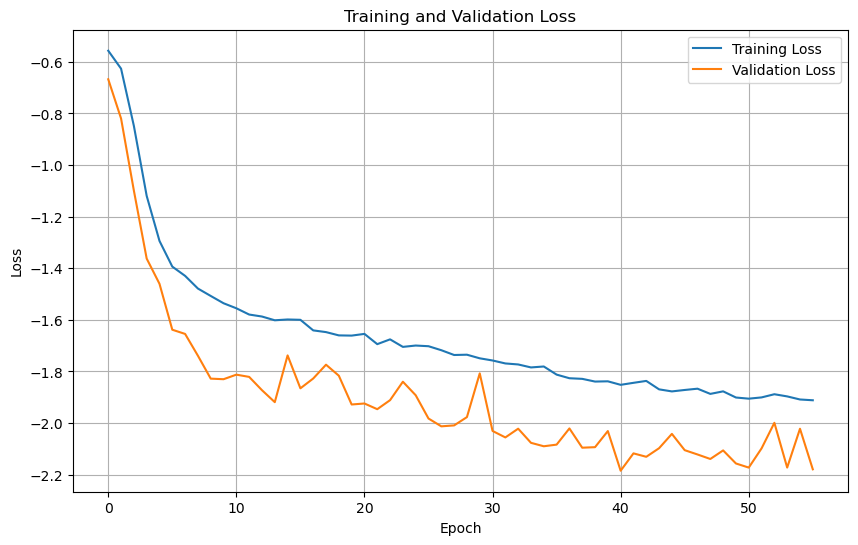

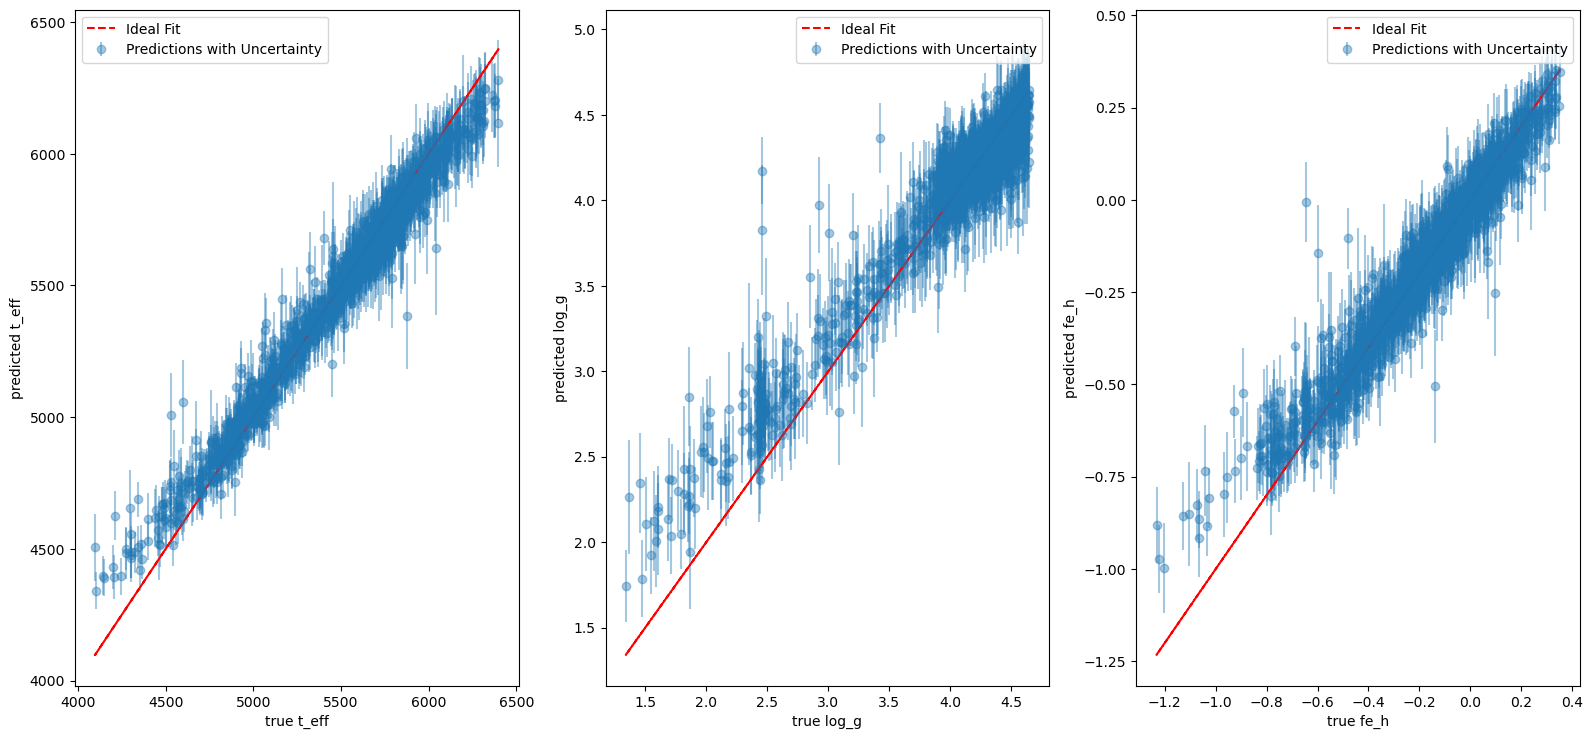

In [13]:
model.load_state_dict(torch.load(f'Deep-Learning/models/{model_choice}_uncertainty_best.pth'))  # Load the best model
model.to(device)

all_predictions, all_true_labels,_,_ = evaluate_model(model, test_loader, loss_function, device)
# denormalize prediction mean, standard deviation, and true labels
all_predictions[:, :n_labels] = denormalize(all_predictions[:, :n_labels], ranges[:n_labels])

normalized_log_std = all_predictions[:, n_labels:]
normalized_std = np.exp(normalized_log_std)  # Convert log standard deviation to standard deviation
denormalized_std = denormalize_std(normalized_std, ranges)
all_predictions[:, n_labels:] = denormalized_std  # Update the predictions with denormalized standard deviation

all_true_labels = denormalize(all_true_labels, ranges)  # Denormalize true labels





# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(f'plots/{model_choice}_training_validation_loss_un.png')

# plots with uncertainty
if calculate_uncertainty:
    plt.figure(figsize=(16,7.5))
    for j in range(n_labels):
        plt.subplot(1, n_labels, j+1)
        
        # Pull the already-calculated standard deviation from the array
        std_for_plot = all_predictions[:, n_labels+j]
        
        # Plot with 2*std for a ~95% confidence interval
        plt.errorbar(all_true_labels[:, j], all_predictions[:, j], 
                     yerr= std_for_plot, 
                     fmt='o', label='Predictions with Uncertainty', alpha=0.4)
                     
        plt.plot(all_true_labels[:, j], all_true_labels[:, j], 'r--', label='Ideal Fit')
        plt.xlabel("true " + labelNames[j])
        plt.ylabel("predicted " + labelNames[j])
        plt.legend()
        
    plt.tight_layout()
    plt.savefig(f'plots/{model_choice}_scatter_with_uncertainty.png')
    plt.show()
else:
    # Scatter plots for predictions without uncertainty
    plt.figure(figsize=(16,7.5))
    for j in range(n_labels):
        plt.subplot(1, n_labels, j+1)
        plt.scatter(all_true_labels[:, j], all_predictions[:, j], label='Predictions', alpha=0.5)
        plt.plot(all_true_labels[:, j], all_true_labels[:, j], 'r--', label='Ideal Fit')
        plt.xlabel("true "+labelNames[j])

Label: t_eff, Mean of errors: -4.9939, Std of errors: 86.6696
Label: log_g, Mean of errors: 0.0254, Std of errors: 0.1997
Label: fe_h, Mean of errors: 0.0062, Std of errors: 0.0736


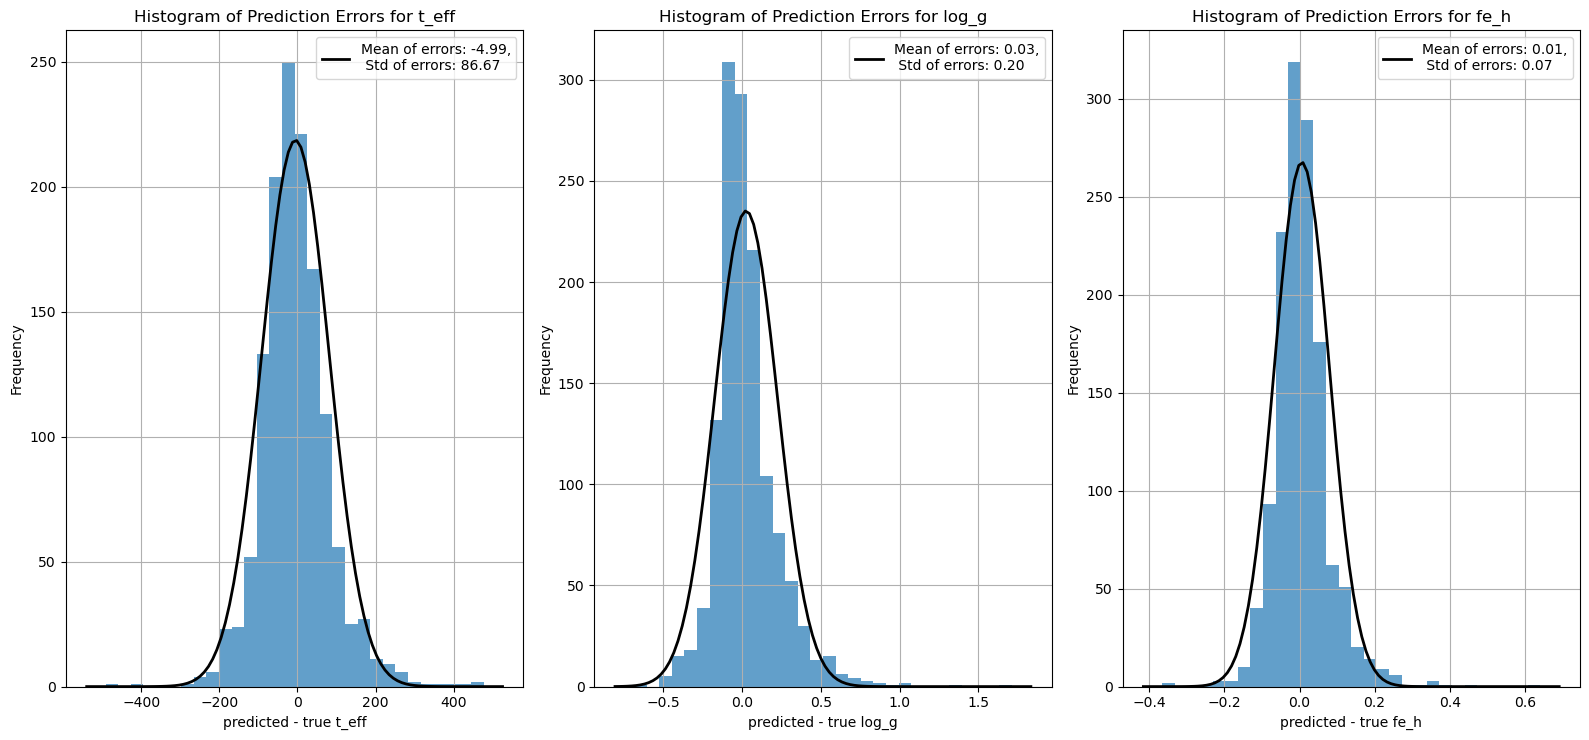

In [14]:
# plot histogram of predicted - true values for each label
plt.figure(figsize=(16,7.5))
for j in range(n_labels):
    plt.subplot(1, n_labels, j+1)
    plt.hist(all_predictions[:, j] - all_true_labels[:, j], bins=30, alpha=0.7)
    plt.xlabel("predicted - true " + labelNames[j])
    plt.ylabel("Frequency")
    plt.title("Histogram of Prediction Errors for " + labelNames[j])
    plt.grid()
    # fit a normal distribution to the histogram and plot it
    mu, std = norm.fit(all_predictions[:, j] - all_true_labels[:, j])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p * len(all_predictions[:, j]) * (xmax - xmin) / 30, 'k', linewidth=2, label=f'Mean of errors: {mu:.2f},\n Std of errors: {std:.2f}')
    plt.legend()
    print(f"Label: {labelNames[j]}, Mean of errors: {mu:.4f}, Std of errors: {std:.4f}")

plt.tight_layout()
plt.savefig(f'plots/{model_choice}_prediction_error_histograms_uncertainty.png')
plt.show()

Label: t_eff, Mean of pulls: 0.0128, Std of pulls: 0.8420
Label: log_g, Mean of pulls: 0.0963, Std of pulls: 0.8926
Label: fe_h, Mean of pulls: 0.0642, Std of pulls: 0.7838


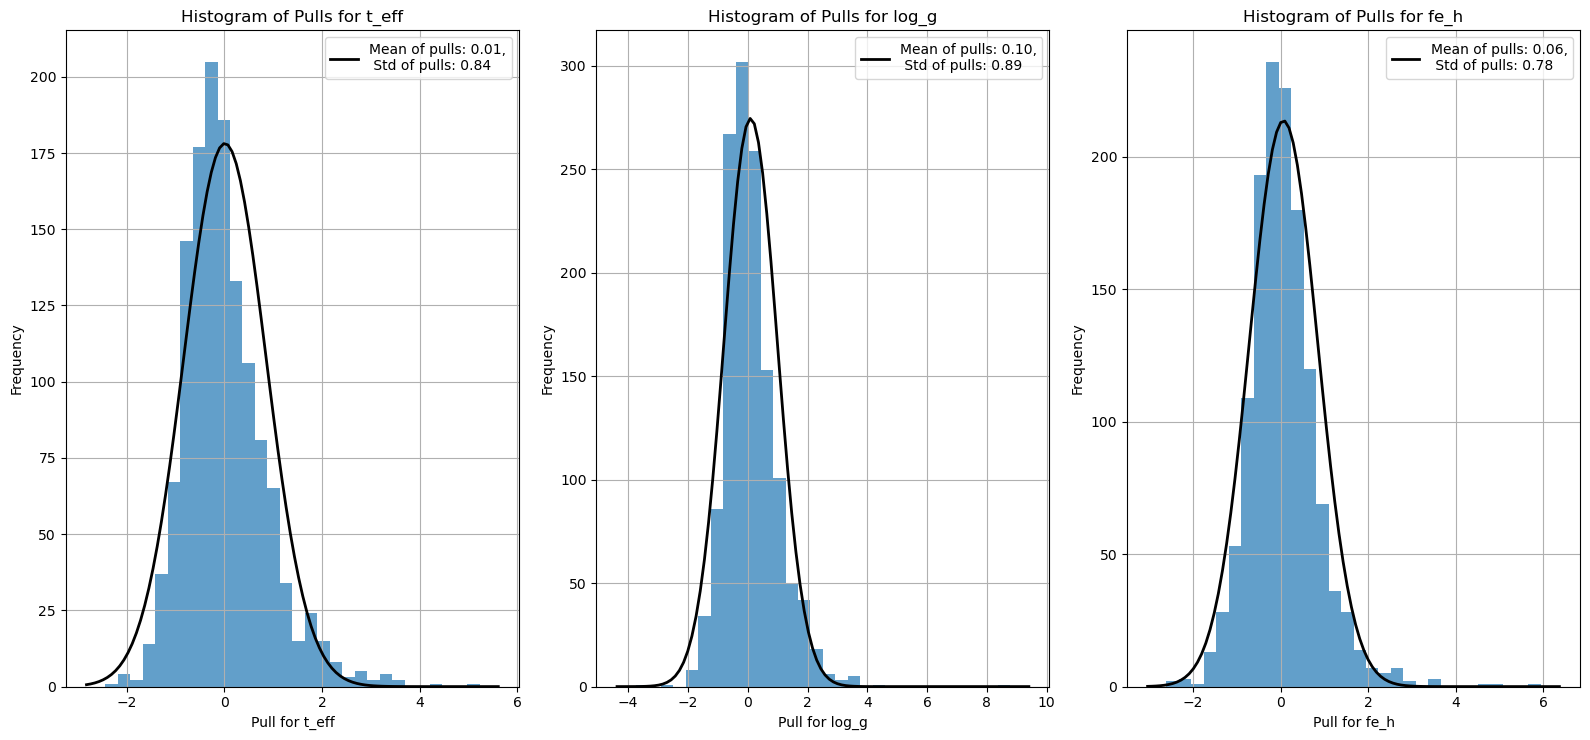

In [15]:
# calculate pull distribution for each label
plt.figure(figsize=(16,7.5))
for j in range(n_labels):
    plt.subplot(1, n_labels, j+1)
    pulls = (all_predictions[:, j] - all_true_labels[:, j]) / all_predictions[:, n_labels+j]
    plt.hist(pulls, bins=30, alpha=0.7)
    plt.xlabel("Pull for " + labelNames[j])
    plt.ylabel("Frequency")
    plt.title("Histogram of Pulls for " + labelNames[j])
    plt.grid()
    # fit a normal distribution to the histogram and plot it
    mu, std = norm.fit(pulls)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p * len(pulls) * (xmax - xmin) / 30, 'k', linewidth=2, label=f'Mean of pulls: {mu:.2f},\n Std of pulls: {std:.2f}')
    plt.legend()
    print(f"Label: {labelNames[j]}, Mean of pulls: {mu:.4f}, Std of pulls: {std:.4f}")

plt.tight_layout()
plt.savefig(f'plots/{model_choice}_pull_histograms_uncertainty.png')
plt.show()

In [16]:
print("\n--- Uncertainty Evaluation ---")

for j in range(n_labels):
    print(f"\nEvaluating: {labelNames[j]}")
    
    y_true = all_true_labels[:, j]
    y_pred = all_predictions[:, j]
    sigma = all_predictions[:, n_labels + j]
    
    # 1. Z-scores
    z_scores = (y_true - y_pred) / sigma
    z_mean = np.mean(z_scores)
    z_std = np.std(z_scores)
    print(f"  Z-score Mean : {z_mean:.3f} (Ideal: 0.0)")
    print(f"  Z-score Std  : {z_std:.3f} (Ideal: 1.0)")
    
    # 2. Empirical Coverage
    coverage_1sigma = np.mean(np.abs(y_true - y_pred) <= 1.0 * sigma) * 100
    coverage_2sigma = np.mean(np.abs(y_true - y_pred) <= 2.0 * sigma) * 100
    print(f"  1-Sigma Coverage : {coverage_1sigma:.1f}% (Ideal: ~68.3%)")
    print(f"  2-Sigma Coverage : {coverage_2sigma:.1f}% (Ideal: ~95.4%)")
    
    # 3. RMSE vs RMV
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    rmv = np.sqrt(np.mean(sigma**2))
    print(f"  RMSE vs RMV  : {rmse:.3f} vs {rmv:.3f} (Ideal: roughly equal)")


--- Uncertainty Evaluation ---

Evaluating: t_eff
  Z-score Mean : -0.013 (Ideal: 0.0)
  Z-score Std  : 0.842 (Ideal: 1.0)
  1-Sigma Coverage : 82.4% (Ideal: ~68.3%)
  2-Sigma Coverage : 96.9% (Ideal: ~95.4%)
  RMSE vs RMV  : 86.813 vs 103.630 (Ideal: roughly equal)

Evaluating: log_g
  Z-score Mean : -0.096 (Ideal: 0.0)
  Z-score Std  : 0.893 (Ideal: 1.0)
  1-Sigma Coverage : 79.7% (Ideal: ~68.3%)
  2-Sigma Coverage : 97.0% (Ideal: ~95.4%)
  RMSE vs RMV  : 0.201 vs 0.206 (Ideal: roughly equal)

Evaluating: fe_h
  Z-score Mean : -0.064 (Ideal: 0.0)
  Z-score Std  : 0.784 (Ideal: 1.0)
  1-Sigma Coverage : 85.3% (Ideal: ~68.3%)
  2-Sigma Coverage : 97.7% (Ideal: ~95.4%)
  RMSE vs RMV  : 0.074 vs 0.089 (Ideal: roughly equal)
